# SEC-MALS Plotting Notebook

Creates publication-quality SEC-MALS chromatograms from ASTRA exports.

**Input format:** Tab-separated ASTRA export with European number format (comma as decimal separator, period as thousands separator).

**Expected column layout:**
```
Columns 0–7 : BSA standard  →  (vol, UV), (vol, dRI), (vol, UV_dup), (vol, LS_raw)
Columns 8–15: Sample         →  (vol, UV), (vol, dRI), (vol, UV_dup), (vol, Mw_Da)
```
The Mw column contains data only inside the integration window set in ASTRA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'pdf.fonttype': 42,   # editable text in Illustrator
    'svg.fonttype': 'none',
})

## 1. Load data

In [2]:
# ── Configure file path here ───────────────────────────────────────────────────
DATA_FILE = Path('/Users/ajakobi/Downloads/20251217_dynA.txt')

# Labels that will appear in plots and legend
SAMPLE_LABEL = 'DynA'
BSA_LABEL    = 'BSA'


# ── Parser ────────────────────────────────────────────────────────────────────
def _eu(s: str) -> float:
    """Parse a European-format number ('1.234,56' → 1234.56)."""
    s = str(s).strip()
    if s in ('', 'nan', 'NaN', 'None'):
        return np.nan
    s = s.replace('.', '')   # strip thousands sep
    s = s.replace(',', '.')  # replace decimal comma
    try:
        return float(s)
    except ValueError:
        return np.nan


def load_astra_export(filepath: Path) -> pd.DataFrame:
    """
    Load a two-sample ASTRA SEC-MALS export file.

    File has 16 tab-separated columns, no row-number prefix.

    Column layout (pairs of volume, signal):
      0–1  : BSA UV
      2–3  : BSA dRI
      4–5  : BSA UV duplicate (same as 0–1)
      6–7  : BSA raw LS (only filled inside the integration window)
      8–9  : Sample UV
      10–11: Sample dRI
      12–13: Sample UV duplicate (same as 8–9)
      14–15: Sample Mw in Da (only filled inside the integration window)
    """
    col_names = [
        'bsa_uv_vol',  'bsa_uv',
        'bsa_ri_vol',  'bsa_ri',
        '_bsa_uv2v',   '_bsa_uv2',
        'bsa_ls_vol',  'bsa_ls',
        'dyna_uv_vol', 'dyna_uv',
        'dyna_ri_vol', 'dyna_ri',
        '_dyna_uv2v',  '_dyna_uv2',
        'dyna_mw_vol', 'dyna_mw_da',
    ]

    rows = []
    with open(filepath, encoding='utf-8') as fh:
        for i, line in enumerate(fh):
            if i == 0:      # header row — skip
                continue
            parts = line.rstrip('\n').split('\t')
            # 16 data columns, no row-number prefix
            vals = [_eu(p) for p in parts[0:16]]
            while len(vals) < 16:
                vals.append(np.nan)
            rows.append(vals)

    return pd.DataFrame(rows, columns=col_names)


df = load_astra_export(DATA_FILE)
print(f'Loaded {len(df):,} data rows from {DATA_FILE.name}')

# ── Quick summary ──────────────────────────────────────────────────────────────
def _rng(col):
    s = df[col].dropna()
    return f'{s.min():.3f} – {s.max():.3f}  (n={len(s):,})'

print(f"\nBSA  UV   volume : {_rng('bsa_uv_vol')} mL")
print(f"BSA  UV   signal : {_rng('bsa_uv')}")
print(f"BSA  dRI  volume : {_rng('bsa_ri_vol')} mL")
print(f"BSA  dRI  signal : {_rng('bsa_ri')}")
print()
print(f"DynA UV   volume : {_rng('dyna_uv_vol')} mL")
print(f"DynA UV   signal : {_rng('dyna_uv')}")
print(f"DynA dRI  volume : {_rng('dyna_ri_vol')} mL")
print(f"DynA dRI  signal : {_rng('dyna_ri')}")
print()
mw_data = df.dropna(subset=['dyna_mw_vol', 'dyna_mw_da'])
print(f"DynA Mw   volume : {mw_data['dyna_mw_vol'].min():.2f} – {mw_data['dyna_mw_vol'].max():.2f} mL  (n={len(mw_data)})")
print(f"DynA Mw   range  : {mw_data['dyna_mw_da'].min()/1e3:.1f} – {mw_data['dyna_mw_da'].max()/1e3:.1f} kDa")
print(f"DynA Mw   median : {mw_data['dyna_mw_da'].median()/1e3:.1f} kDa")

Loaded 6,471 data rows from 20251217_dynA.txt

BSA  UV   volume : 10.001 – 36.491  (n=6,470) mL
BSA  UV   signal : -0.504 – 1.000  (n=6,470)
BSA  dRI  volume : 9.942 – 36.432  (n=6,470) mL
BSA  dRI  signal : -0.004 – 1.000  (n=6,470)

DynA UV   volume : 0.002 – 26.492  (n=6,470) mL
DynA UV   signal : -0.135 – 1.000  (n=6,470)
DynA dRI  volume : -0.057 – 26.433  (n=6,470) mL
DynA dRI  signal : -0.001 – 1.000  (n=6,470)

DynA Mw   volume : 12.95 – 13.63 mL  (n=69)
DynA Mw   range  : 121.5 – 152.8 kDa
DynA Mw   median : 133.0 kDa


## 2. Quick overview — all signals

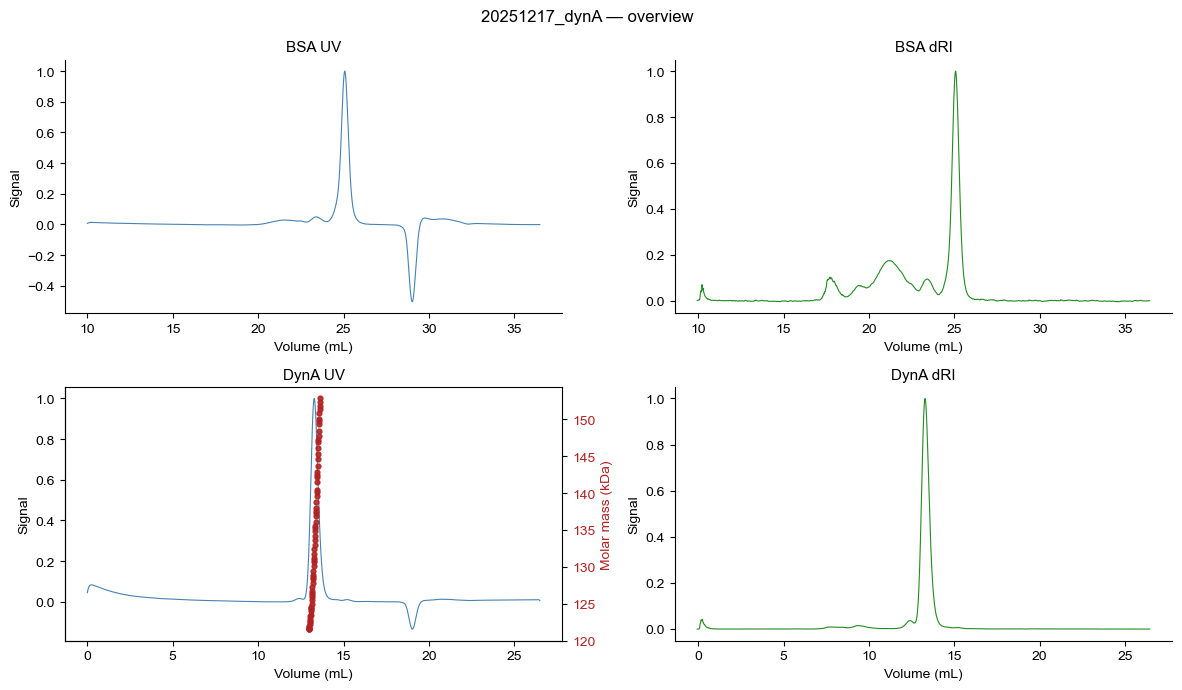

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

pairs = [
    ('bsa_uv_vol',  'bsa_uv',      'BSA UV',        axes[0, 0], 'steelblue'),
    ('bsa_ri_vol',  'bsa_ri',      'BSA dRI',        axes[0, 1], 'forestgreen'),
    ('dyna_uv_vol', 'dyna_uv',     'DynA UV',        axes[1, 0], 'steelblue'),
    ('dyna_ri_vol', 'dyna_ri',     'DynA dRI',       axes[1, 1], 'forestgreen'),
]

for vcol, scol, title, ax, color in pairs:
    sub = df[[vcol, scol]].dropna()
    ax.plot(sub[vcol], sub[scol], color=color, lw=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Volume (mL)')
    ax.set_ylabel('Signal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add Mw on DynA UV panel
ax_dyna = axes[1, 0]
ax_mw   = ax_dyna.twinx()
ax_mw.scatter(mw_data['dyna_mw_vol'], mw_data['dyna_mw_da'] / 1e3,
              color='firebrick', s=12, zorder=5, alpha=0.9)
ax_mw.set_ylabel('Molar mass (kDa)', color='firebrick')
ax_mw.tick_params(axis='y', labelcolor='firebrick')

fig.suptitle(f'{DATA_FILE.stem} — overview', fontsize=12)
fig.tight_layout()
plt.show()

## 3. Publication-quality SEC-MALS plot

/var/folders/g0/l5g1vzlx1836242dlnzx6gq9w2cnw7/T/ipykernel_3662/954029144.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


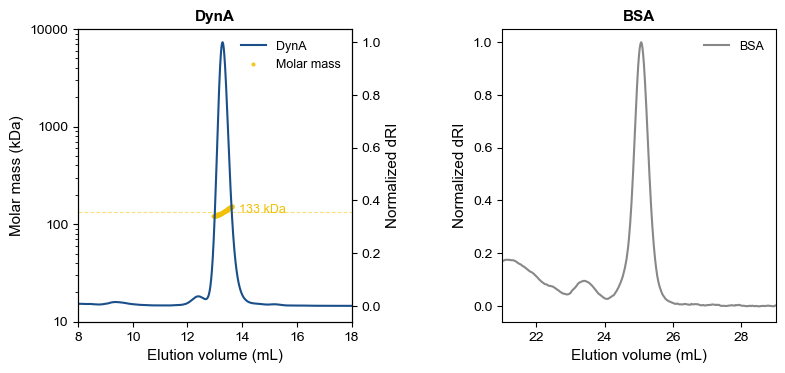

In [4]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# DynA peak: ~13.3 mL   BSA (reference) peak: ~25.1 mL
DYNA_VOL_RANGE = (8.0, 18.0)    # mL
BSA_VOL_RANGE  = (21.0, 29.0)   # mL  (set to None to show only DynA)

# Molar mass y-axis (left), logarithmic scale — must not include 0
MW_YLIM = (10, 10000)   # kDa

# Only show Mw dots where dRI ≥ this fraction of peak
MW_RI_THRESHOLD = 0.10

# Colors
C_MW   = "#f0c106"   # red  — molar mass (left axis)
C_DYNA = '#1a4f8a'   # blue — dRI trace  (right axis)
C_BSA  = '#888888'   # gray — BSA reference


# ── Helper ────────────────────────────────────────────────────────────────────
def _slice(df, vcol, scol, vmin, vmax):
    m = (df[vcol] >= vmin) & (df[vcol] <= vmax)
    return df.loc[m, vcol].values, df.loc[m, scol].values


# ── Layout ────────────────────────────────────────────────────────────────────
show_bsa = BSA_VOL_RANGE is not None
if show_bsa:
    fig, (ax_d, ax_b) = plt.subplots(1, 2, figsize=(9, 3.8),
                                      gridspec_kw={'wspace': 0.55})
else:
    fig, ax_d = plt.subplots(1, 1, figsize=(4.5, 3.8))


# ── DynA panel: left = Mw (log), right = dRI ──────────────────────────────────
ax_ri = ax_d.twinx()   # right axis — dRI

# Right axis: normalized dRI
vd, sd = _slice(df, 'dyna_ri_vol', 'dyna_ri', *DYNA_VOL_RANGE)
sd_norm = sd / sd.max() if sd.max() > 0 else sd
ax_ri.plot(vd, sd_norm, color=C_DYNA, lw=1.5, label=SAMPLE_LABEL)
ax_ri.set_ylim(-0.06, 1.05)
ax_ri.set_ylabel('Normalized dRI', color='#000000', fontsize=11)
ax_ri.tick_params(axis='y', labelcolor='#000000')

# Left axis: molar mass scatter (log scale)
mw_sub = mw_data[
    (mw_data['dyna_mw_vol'] >= DYNA_VOL_RANGE[0]) &
    (mw_data['dyna_mw_vol'] <= DYNA_VOL_RANGE[1])
].copy()
if len(mw_sub) > 0 and len(vd) > 0:
    ri_at_mw = np.interp(mw_sub['dyna_mw_vol'], vd, sd_norm)
    mw_sub = mw_sub[ri_at_mw >= MW_RI_THRESHOLD]

mw_kda = mw_sub['dyna_mw_da'].values / 1e3
vol_mw = mw_sub['dyna_mw_vol'].values

ax_d.scatter(vol_mw, mw_kda, color=C_MW, s=4, zorder=5, alpha=0.8, label='Molar mass')

if len(mw_kda) > 0:
    mw_median = float(np.median(mw_kda))
    ax_d.axhline(mw_median, color=C_MW, lw=0.8, ls='--', alpha=0.5)
    ax_d.annotate(
        f'{mw_median:.0f} kDa',
        xy=(vol_mw.max(), mw_median),
        xytext=(5, 2), textcoords='offset points',
        color=C_MW, fontsize=9, va='center', ha='left',
    )

ax_d.set_xlim(DYNA_VOL_RANGE)
ax_d.set_ylim(*MW_YLIM)
ax_d.set_yscale('log')
ax_d.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
ax_d.set_xlabel('Elution volume (mL)', fontsize=11)
ax_d.set_ylabel('Molar mass (kDa)', color='#000000', fontsize=11)
ax_d.tick_params(axis='y', labelcolor='#000000')
ax_d.set_title(SAMPLE_LABEL, fontsize=11, fontweight='bold')

# Full box border
for ax in (ax_d, ax_ri):
    for spine in ax.spines.values():
        spine.set_visible(True)

# Legend
h1, l1 = ax_ri.get_legend_handles_labels()
h2, l2 = ax_d.get_legend_handles_labels()
ax_d.legend(h1 + h2, l1 + l2, loc='upper right', frameon=False, fontsize=9)


# ── BSA panel (reference) ─────────────────────────────────────────────────────
if show_bsa:
    vb, sb = _slice(df, 'bsa_ri_vol', 'bsa_ri', *BSA_VOL_RANGE)
    sb_norm = sb / sb.max() if (len(sb) > 0 and sb.max() > 0) else sb

    ax_b.plot(vb, sb_norm, color=C_BSA, lw=1.5, label=BSA_LABEL)
    ax_b.set_xlim(BSA_VOL_RANGE)
    ax_b.set_ylim(-0.06, 1.05)
    ax_b.set_xlabel('Elution volume (mL)', fontsize=11)
    ax_b.set_ylabel('Normalized dRI', fontsize=11)
    ax_b.set_title(BSA_LABEL, fontsize=11, fontweight='bold')
    for spine in ax_b.spines.values():
        spine.set_visible(True)
    ax_b.legend(loc='upper right', frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

## 5. Save figure

In [5]:
# ── Run cells 3–4 first, then save the figure you want ────────────────────────
OUTPUT_STEM = DATA_FILE.stem   # e.g. '20251217_dynA'

# Save the last figure
for ext in ('pdf', 'png'):
    out = DATA_FILE.parent / f'{OUTPUT_STEM}_sec_mals.{ext}'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'Saved → {out}')

Saved → /Users/ajakobi/Downloads/20251217_dynA_sec_mals.pdf
Saved → /Users/ajakobi/Downloads/20251217_dynA_sec_mals.png
